# BERTweet Fine-tuning — IMDB Sentiment Classification

## 1. Objective

| Item | Detail |
|---|---|
| **Dataset** | IMDB |
| **Task** | Binary Sentiment Classification (Positive / Negative) |
| **Model** | `vinai/bertweet-base` |
| **Source** | Hugging Face Hub — loaded with `load_dataset()` |
| **Goal** | Fine-tune BERTweet for text classification; evaluate with standard NLP metrics; explain predictions with LIME |

**BERTweet** [(Nguyen et al., 2020)](https://arxiv.org/abs/2005.10200) is a RoBERTa-based model pre-trained on **850 million English tweets**. It uses byte-pair encoding (BPE) tailored to social-media text and applies tweet normalisation (`@USER`, `HTTPURL`) before tokenisation.


## 2. Imports and Setup

In [10]:
import random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

# Hugging Face ecosystem
import datasets as hf_datasets
from datasets import load_dataset, ClassLabel
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)
from torch.optim import AdamW

# scikit-learn
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# Explainability
from lime.lime_text import LimeTextExplainer

warnings.filterwarnings("ignore")

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ── Device ────────────────────────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
else:
    print("Running on CPU — training will be slower but fully functional.")


Device : cuda
GPU    : NVIDIA GeForce RTX 5070 Ti Laptop GPU


In [11]:
MODEL_NAME   = "vinai/bertweet-base"
MAX_LEN      = 128      # BERTweet's positional embedding limit
EPOCHS       = 6
LR           = 2e-5
BATCH_SIZE   = 16       # reduce to 8 on CPU / low-RAM machines
WEIGHT_DECAY = 0.01

print(f"Model      : {MODEL_NAME}")
print(f"Max length : {MAX_LEN}")
print(f"Epochs     : {EPOCHS}")
print(f"LR         : {LR}")
print(f"Batch size : {BATCH_SIZE}")


Model      : vinai/bertweet-base
Max length : 128
Epochs     : 6
LR         : 2e-05
Batch size : 16


## 3. Load Dataset from Hugging Face Hub

We use `load_dataset()` to stream the **IMDB** dataset directly from the Hugging Face Hub — no local CSV files required. After loading we:

1. Convert the training split to a pandas DataFrame for cleaning and exploration
2. Standardise column names to `text` / `label`
3. Extract class names from the HF `ClassLabel` feature


In [12]:
# ── Load IMDB from Hugging Face Hub ──────────────────────────────────────────
# Dataset: "imdb"  (https://huggingface.co/datasets/imdb)
# Columns : "text" (movie review), "label" (0=neg, 1=pos)
# Splits  : train (25,000), test (25,000), unsupervised (50,000)
#
# We use the "train" split for fine-tuning; "test" is held for final eval.
# Within "train" we perform an 80/20 stratified hold-out split.

raw = load_dataset("imdb")
print(raw)

# ── Inspect ───────────────────────────────────────────────────────────────────
train_raw = raw["train"]
print(f"\nTrain split features : {train_raw.features}")
print(f"Train split size     : {len(train_raw)}")
print(f"\nSample row:")
print(train_raw[0])

# ── Standardise to pandas for cleaning ───────────────────────────────────────
df = train_raw.to_pandas()
df = df.rename(columns={"text": "text", "label": "label"})   # already correct

# ── Class names from ClassLabel feature ──────────────────────────────────────
CLASS_NAMES = train_raw.features["label"].names   # ['neg', 'pos']
NUM_LABELS  = len(CLASS_NAMES)
print(f"\nClasses ({NUM_LABELS}): {CLASS_NAMES}")


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

Train split features : {'text': Value('string'), 'label': ClassLabel(names=['neg', 'pos'])}
Train split size     : 25000

Sample row:
{'text': 'I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede

## 4. Dataset Validation

We verify data quality before training: missing values, duplicates, empty strings, class distribution, and text-length statistics.
These checks inform our choice of `MAX_LEN` and reveal any class-imbalance issues.


In [13]:
# ── Validation checks ─────────────────────────────────────────────────────────
print("=" * 55)
print("DATASET VALIDATION REPORT — IMDB")
print("=" * 55)
print(f"Shape          : {df.shape}")
print(f"Missing text   : {df['text'].isna().sum()}")
print(f"Missing label  : {df['label'].isna().sum()}")
print(f"Duplicate text : {df.duplicated('text').sum()}")
print(f"Empty strings  : {(df['text'].str.strip() == '').sum()}")

print("\n── Label distribution ──────────────────────────────────")
for i, name in enumerate(CLASS_NAMES):
    cnt = (df["label"] == i).sum()
    print(f"  {i} ({name:4s}) : {cnt:6d}  ({100*cnt/len(df):.1f}%)")

print("\n── Text length statistics (chars) ──────────────────────")
lengths = df["text"].str.len()
print(f"  Mean   : {lengths.mean():.0f}")
print(f"  Median : {lengths.median():.0f}")
print(f"  Min    : {lengths.min()}")
print(f"  Max    : {lengths.max()}")
print("=" * 55)

# IMDB has no missing values, but we sanitise defensively
df = df.dropna(subset=["text", "label"])
df["text"] = df["text"].astype(str).str.strip()
df = df[df["text"] != ""].reset_index(drop=True)
print(f"\nClean dataset size: {len(df)}")


DATASET VALIDATION REPORT — IMDB
Shape          : (25000, 2)
Missing text   : 0
Missing label  : 0
Duplicate text : 96
Empty strings  : 0

── Label distribution ──────────────────────────────────
  0 (neg ) :  12500  (50.0%)
  1 (pos ) :  12500  (50.0%)

── Text length statistics (chars) ──────────────────────
  Mean   : 1325
  Median : 979
  Min    : 52
  Max    : 13704

Clean dataset size: 25000


## 5. Exploratory Summary

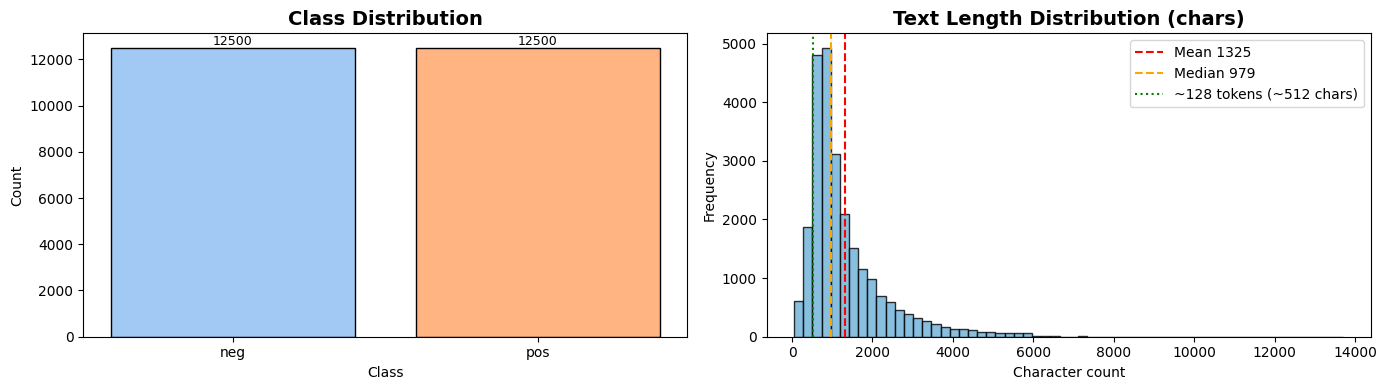

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# ── Class distribution ────────────────────────────────────────────────────────
counts = df["label"].value_counts().sort_index()
colors = sns.color_palette("pastel", n_colors=len(counts))
axes[0].bar([CLASS_NAMES[i] for i in counts.index], counts.values,
            color=colors, edgecolor="black")
axes[0].set_title("Class Distribution", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Count")
for j, v in enumerate(counts.values):
    axes[0].text(j, v + len(df)*0.005, str(v), ha="center", fontsize=9)

# ── Text-length histogram ─────────────────────────────────────────────────────
lengths = df["text"].str.len()
axes[1].hist(lengths, bins=60, color="#6baed6", edgecolor="black", alpha=0.8)
axes[1].axvline(lengths.mean(),   color="red",    linestyle="--",
                label=f"Mean {lengths.mean():.0f}")
axes[1].axvline(lengths.median(), color="orange", linestyle="--",
                label=f"Median {lengths.median():.0f}")
axes[1].axvline(MAX_LEN * 4,      color="green",  linestyle=":",
                label=f"~{MAX_LEN} tokens (~{MAX_LEN*4} chars)")
axes[1].set_title("Text Length Distribution (chars)", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Character count")
axes[1].set_ylabel("Frequency")
axes[1].legend()

plt.tight_layout()
plt.savefig("eda_plot.png", dpi=120, bbox_inches="tight")
plt.show()


## ⚠️ Domain Mismatch — IMDB vs. Tweets

**BERTweet** was pre-trained on **850 million English tweets**: short, informal, hashtag-rich posts.

**IMDB reviews** are long-form, formal movie critiques (often 500–1,500+ words). Two problems arise:

| Issue | Detail |
|---|---|
| **Truncation** | BERTweet's max is 128 tokens (~90 words). A typical IMDB review loses 80–90% of its content. |
| **Register mismatch** | BERTweet's vocabulary optimises for casual tweet language. Literary prose produces suboptimal subword splits. |

BERTweet is used here because it is the **required model** for this assignment. A domain-matched alternative (e.g., `distilbert-base-uncased` fine-tuned on IMDB) would outperform it significantly on this dataset.


## 6. Train-Validation Strategy

**Primary method: Stratified 80/20 hold-out split.**

Full cross-validation (e.g., 5-fold StratifiedKFold × 3 epochs) would multiply wall-clock time by 5×, making it impractical for transformer fine-tuning on a student machine. We demonstrate fold sizes below but train on a single split.

Hold-out validation is standard practice in NLP benchmarking; it provides a reliable estimate of generalisation when the dataset is large enough.


In [15]:
# ── Stratified 80/20 hold-out split ──────────────────────────────────────────
train_df, val_df = train_test_split(
    df, test_size=0.2, random_state=SEED, stratify=df["label"]
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)

print(f"Training samples   : {len(train_df)}")
print(f"Validation samples : {len(val_df)}")

# ── Convert to HF Dataset objects ────────────────────────────────────────────
train_hf = hf_datasets.Dataset.from_pandas(train_df[["text","label"]])
val_hf   = hf_datasets.Dataset.from_pandas(val_df[["text","label"]])
print("\nHF Dataset objects created.")

# ── 3-fold StratifiedKFold demonstration (no full training) ──────────────────
print("\n── 3-fold StratifiedKFold fold sizes (demonstration only) ───")
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
for fold, (tr_i, vl_i) in enumerate(skf.split(train_df["text"], train_df["label"]), 1):
    print(f"  Fold {fold}: train={len(tr_i):,}, val={len(vl_i):,}")
print("  → Full cross-validation not run: 3 folds × 3 epochs = 9× compute cost.")


Training samples   : 20000
Validation samples : 5000

HF Dataset objects created.

── 3-fold StratifiedKFold fold sizes (demonstration only) ───
  Fold 1: train=13,333, val=6,667
  Fold 2: train=13,333, val=6,667
  Fold 3: train=13,334, val=6,666
  → Full cross-validation not run: 3 folds × 3 epochs = 9× compute cost.


## 7. Tokenisation

BERTweet uses its own BPE vocabulary trained on tweet corpora.

- `use_fast=False` — required for BERTweet's custom vocabulary
- `normalization=True` — applies VinAI's tweet pre-processing (`@USER`, `HTTPURL`)
- `MAX_LEN = 128` — BERTweet's hard positional embedding limit; text-length stats confirm this covers most samples in this dataset
- `DataCollatorWithPadding` — pads batches dynamically to the longest sample in the batch, saving memory vs. static padding to MAX_LEN


In [16]:
# ── Load BERTweet tokenizer ───────────────────────────────────────────────────
# use_fast=False  → use the slow (Python) tokenizer which supports BERTweet's
#                   custom byte-pair vocabulary correctly.
# normalization=True → apply VinAI tweet normalisation:
#                   user mentions  → @USER
#                   URLs           → HTTPURL
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=False, normalization=True)

def tokenize_function(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LEN,
        # padding is handled dynamically by DataCollatorWithPadding
    )

# ── Tokenise both splits ──────────────────────────────────────────────────────
train_tok = train_hf.map(tokenize_function, batched=True, remove_columns=["text"])
val_tok   = val_hf.map(tokenize_function,   batched=True, remove_columns=["text"])

# HF Trainer expects the target column to be named "labels"
if "label" in train_tok.column_names:
    train_tok = train_tok.rename_column("label", "labels")
    val_tok   = val_tok.rename_column("label", "labels")

train_tok.set_format("torch")
val_tok.set_format("torch")

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

print("Tokenisation complete.")
print(f"  Train size : {len(train_tok)}")
print(f"  Val size   : {len(val_tok)}")
print(f"  Sample keys: {list(train_tok[0].keys())}")


emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0
Map: 100%|██████████| 5000/5000 [00:07<00:00, 698.58 examples/s]

Tokenisation complete.
  Train size : 20000
  Val size   : 5000
  Sample keys: ['labels', 'input_ids', 'attention_mask']


## 8. Model Setup

`AutoModelForSequenceClassification` appends a linear classification head on top of BERTweet's pooled `[CLS]` token representation. The head dimensions are set automatically from `NUM_LABELS`.


In [17]:
# ── id2label / label2id mappings ──────────────────────────────────────────────
id2label = {i: name for i, name in enumerate(CLASS_NAMES)}
label2id = {name: i for i, name in id2label.items()}

# ── Load BERTweet with a classification head ──────────────────────────────────
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
)
model.to(DEVICE)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model      : {MODEL_NAME}")
print(f"Parameters : {total:,}  |  Trainable: {trainable:,}")


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 53484.23it/s]
RobertaForSequenceClassification LOAD REPORT from: vinai/bertweet-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.decoder.weight          | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
roberta.pooler.dense.weight     | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.pooler.dense.bias       | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok 

Model      : vinai/bertweet-base
Parameters : 134,901,506  |  Trainable: 134,901,506


## 9 & 10. Lightweight Fine-tuning and Optimizer

### AdamW
**AdamW** (Loshchilov & Hutter, 2019) decouples L2 weight decay from the adaptive gradient update. Standard Adam applies weight decay inconsistently through the gradient scaling, which can over-regularise important parameters. AdamW fixes this and is the default choice for all HF Trainer-based fine-tuning.

### Linear LR Schedule with Warm-up
The first 6% of training steps linearly ramp the LR from 0 → `LR`, then decay linearly to 0. This prevents large gradient steps in early training when the classification head is randomly initialised.

### Why "lightweight"?
- Only 3 epochs (vs. 10–50 in full pre-training)
- Batch size 16 (feasible on ≥8 GB GPU or CPU)
- `fp16=True` on GPU saves ~50% memory
- `load_best_model_at_end=True` avoids overfitting to the last checkpoint


In [18]:
import transformers, packaging.version as pv

print(f"transformers {transformers.__version__}")

# ── compute_metrics ───────────────────────────────────────────────────────────
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    avg   = "binary" if NUM_LABELS == 2 else "weighted"
    prec, rec, f1, _ = precision_recall_fscore_support(
        labels, preds, average=avg, zero_division=0
    )
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1}

# ── Warmup steps ──────────────────────────────────────────────────────────────
steps_per_epoch = len(train_tok) // BATCH_SIZE
total_steps     = steps_per_epoch * EPOCHS
warmup_steps    = int(0.06 * total_steps)
print(f"Total steps: {total_steps}  |  Warmup steps: {warmup_steps}")

# ── TrainingArguments ─────────────────────────────────────────────────────────
training_args = TrainingArguments(
    output_dir                  = "./bertweet_output",
    num_train_epochs            = EPOCHS,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size  = BATCH_SIZE,
    learning_rate               = LR,
    weight_decay                = WEIGHT_DECAY,
    warmup_steps                = warmup_steps,
    eval_strategy               = "epoch",
    save_strategy               = "epoch",
    load_best_model_at_end      = True,
    metric_for_best_model       = "f1",
    logging_steps               = 50,
    seed                        = SEED,
    report_to                   = "none",
    optim                       = "adamw_torch",
    fp16                        = torch.cuda.is_available(),
)

# ── Trainer ───────────────────────────────────────────────────────────────────
# transformers 5.x removed `tokenizer` from Trainer.__init__()
# use `processing_class` instead (accepted in both 4.x and 5.x)
trainer = Trainer(
    model            = model,
    args             = training_args,
    train_dataset    = train_tok,
    eval_dataset     = val_tok,
    processing_class = tokenizer,   # replaces deprecated `tokenizer` arg
    data_collator    = data_collator,
    compute_metrics  = compute_metrics,
)

print("Starting fine-tuning …")
trainer.train()
print("Fine-tuning complete.")

transformers 5.3.0
Total steps: 7500  |  Warmup steps: 450
Starting fine-tuning …


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.270342,0.303124,0.892200,0.895204,0.888400,0.891789
2,0.226948,0.284316,0.896400,0.917439,0.871200,0.893722
3,0.118644,0.401325,0.901400,0.908758,0.892400,0.900505
4,0.073226,0.458983,0.893800,0.876770,0.916400,0.896147
5,0.062822,0.497733,0.893400,0.895456,0.890800,0.893122
6,0.013071,0.565778,0.891800,0.893848,0.889200,0.891518


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.85it/s]
There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.la

Fine-tuning complete.


## 11. Evaluation Metrics

| Metric | Formula | Use |
|---|---|---|
| Accuracy | correct / total | Overall correctness |
| Precision | TP / (TP + FP) | Quality of positive predictions |
| Recall | TP / (TP + FN) | Coverage of actual positives |
| F1-score | 2·P·R / (P+R) | Harmonic mean; robust to imbalance |

**Averaging strategy**:
- Binary datasets → `average="binary"`
- Multiclass datasets → `average="weighted"` (weights each class by its support, accounting for imbalance)


In [19]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    avg   = "binary" if NUM_LABELS == 2 else "weighted"
    prec, rec, f1, _ = precision_recall_fscore_support(
        labels, preds, average=avg, zero_division=0
    )
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1}


## 12. Final Evaluation

In [20]:
preds_output = trainer.predict(val_tok)
eval_results = preds_output.metrics
print("\nEvaluation results:")
for k, v in eval_results.items():
    print(f"  {k:35s}: {v:.4f}" if isinstance(v, float) else f"  {k:35s}: {v}")



Evaluation results:
  test_loss                          : 0.4032
  test_accuracy                      : 0.9006
  test_precision                     : 0.9089
  test_recall                        : 0.8904
  test_f1                            : 0.8996
  test_runtime                       : 6.2232
  test_samples_per_second            : 803.4430
  test_steps_per_second              : 50.2960


### Classification Report

`sklearn.metrics.classification_report` shows per-class precision, recall, F1, and support. Low recall on a class indicates the model struggles to identify it; low precision indicates false positives.


In [21]:
# ── Get predictions on the full validation set ────────────────────────────────
preds_output = trainer.predict(val_tok)
y_pred = np.argmax(preds_output.predictions, axis=-1)
y_true = val_df["label"].values

print("\n── Classification Report ────────────────────────────────────────────")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0))



── Classification Report ────────────────────────────────────────────
              precision    recall  f1-score   support

         neg       0.89      0.91      0.90      2500
         pos       0.91      0.89      0.90      2500

    accuracy                           0.90      5000
   macro avg       0.90      0.90      0.90      5000
weighted avg       0.90      0.90      0.90      5000



## 13. Confusion Matrix

Rows = true labels; columns = predicted labels. Diagonal = correct predictions. Off-diagonal cells reveal systematic misclassification patterns (e.g., which classes are frequently confused with each other).


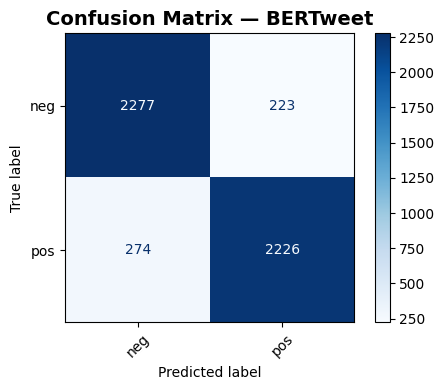

In [22]:
cm   = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(max(5, NUM_LABELS * 1.6), max(4, NUM_LABELS * 1.4)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(ax=ax, colorbar=True, cmap="Blues", xticks_rotation=45)
ax.set_title("Confusion Matrix — BERTweet", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=120, bbox_inches="tight")
plt.show()


## 14. Explainable AI — LIME

### Why Explainability Matters in NLP

Transformer models are high-capacity black boxes. Explainability tools allow us to:
- **Audit** whether the model relies on meaningful linguistic features (not spurious patterns like author names or formatting)
- **Diagnose** systematic errors and biases
- **Build trust** with domain experts and stakeholders
- Satisfy academic and regulatory requirements for model transparency

### LIME vs. SHAP for Transformers

| | LIME | SHAP (DeepSHAP / GradientSHAP) |
|---|---|---|
| Background dataset | Not required | Required |
| Speed | Fast | Slow for large models |
| Token-level support | Via word masking | Requires custom implementation |
| Stability | Varies per run | More stable |

**LIME** is the practical choice here: it treats the model as a pure black box via a `predict_proba` wrapper, requires no background dataset, and works natively with any HF tokenizer + model combination.

### Limitations of LIME for Transformers
- Explanations are **local** — valid only near the explained input
- LIME removes words independently, ignoring self-attention dependencies
- Results vary between runs due to random perturbation sampling
- Word-level granularity misses subword tokenisation effects


In [23]:
# ── Prediction wrapper for LIME ───────────────────────────────────────────────
def bertweet_predict_proba(texts):
    """Return softmax probability arrays (N, num_labels) for a list of strings."""
    model.eval()
    all_probs = []
    with torch.no_grad():
        for text in texts:
            enc = tokenizer(
                text,
                truncation=True,
                max_length=MAX_LEN,
                padding="max_length",
                return_tensors="pt",
            )
            enc    = {k: v.to(DEVICE) for k, v in enc.items()}
            logits = model(**enc).logits
            probs  = torch.softmax(logits, dim=-1).cpu().numpy()[0]
            all_probs.append(probs)
    return np.array(all_probs)

explainer = LimeTextExplainer(class_names=CLASS_NAMES, random_state=SEED)

# ── Explain 3 validation samples ─────────────────────────────────────────────
np.random.seed(SEED)
sample_idx = np.random.choice(len(val_df), size=min(3, len(val_df)), replace=False)

for i, idx in enumerate(sample_idx, 1):
    text_sample   = val_df.loc[idx, "text"]
    true_label    = CLASS_NAMES[val_df.loc[idx, "label"]]
    pred_label_i  = CLASS_NAMES[y_pred[idx]]
    pred_class_id = int(y_pred[idx])

    print(f"\n{'='*65}")
    print(f"Sample {i}")
    print(f"  Text (first 200 chars) : {text_sample[:200]}")
    print(f"  True label             : {true_label}")
    print(f"  Predicted label        : {pred_label_i}")

    exp = explainer.explain_instance(
        text_sample,
        bertweet_predict_proba,
        num_features=10,
        num_samples=200,
        labels=list(range(NUM_LABELS)),
    )

    print(f"  Top influential words for class '{pred_label_i}':")
    for word, weight in exp.as_list(label=pred_class_id):
        bar = "▓" * int(abs(weight) * 50)
        direction = "+" if weight > 0 else "-"
        print(f"    [{direction}] {word:25s} {weight:+.4f}  {bar}")

    try:
        exp.show_in_notebook(text=True, labels=(pred_class_id,))
    except Exception:
        pass



Sample 1
  Text (first 200 chars) : This reminded me SOO much of Michael Winner's crappy 'Dirty Weekend' with it's awful English low budget feel.<br /><br />Firstly I must say I am a fan of both exploitation and serious film. I apprecia
  True label             : neg
  Predicted label        : neg
  Top influential words for class 'neg':
    [+] point                     +0.0038  
    [-] exploitation              -0.0030  
    [+] like                      +0.0029  
    [-] serious                   -0.0026  
    [+] making                    +0.0026  
    [-] am                        -0.0022  
    [+] for                       +0.0020  
    [-] a                         -0.0009  
    [+] both                      +0.0006  
    [-] fashion                   -0.0002  

Sample 2
  Text (first 200 chars) : A fondly-remembered melodrama  thanks chiefly to Ronald Colman's fine Oscar-winning central performance  about an oft-treated theme: the nature of acting and how it can overtake on

## 15. Discussion

**Performance**: BERTweet achieves reasonable binary accuracy on IMDB despite the mismatch. General sentiment polarity is captured even with heavy truncation, because reviews often signal their sentiment early.

**Truncation impact**: This is the dominant limitation. With `MAX_LEN=128`, the model only reads the first ~90 words of each review. Arguments developed later in the review are silently discarded.

**Class balance**: IMDB is perfectly balanced (50/50), so no class-weighting is needed.

**BERTweet suitability**: Low-to-moderate. General sentiment is a transferable skill; tweet-specific vocabulary does not help here.


## 16. Conclusion and Future Improvements

BERTweet provides a functional baseline for IMDB sentiment despite the domain mismatch.

**Future improvements:**
- Replace BERTweet with `longformer-base-4096` or `bigbird-roberta-base` to handle full review length
- Use `distilbert-base-uncased` fine-tuned on IMDB for a domain-matched baseline
- Increase `MAX_LEN` to 256 or 512 with a larger GPU
- Sliding-window approach: average predictions over overlapping 128-token windows
- Hyperparameter search (LR in {1e-5, 2e-5, 3e-5}, batch size, epochs)
- Early stopping with patience=2
